In [0]:
patients=spark.read.csv("/Volumes/healthcare1/healthcare/filestorage/patient.csv").toDF("patient_id","patient_name","city","state","age","gender","insurance_status")
patients.show()

+----------+------------+---------+-----------+---+------+----------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|
+----------+------------+---------+-----------+---+------+----------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|
|      P106|  Neha Singh|     Pune|Maharashtra| 38|Female|        Inactive|
|      P107| Arjun Verma|Hyderabad|  Telangana| 26|  Male|          Active|
|      P108|  Meera Nair|    Kochi|     Kerala| 48|Female|          Active|
+----------+------------+---------+-----------+---+------+----------------+



In [0]:
doctor=spark.read.csv("/Volumes/healthcare1/healthcare/filestorage/doctor.csv").toDF("doctor_id","doctor_name","department","city","consultation_fee")
doctor.show()

+---------+-----------+-----------+---------+----------------+
|doctor_id|doctor_name| department|     city|consultation_fee|
+---------+-----------+-----------+---------+----------------+
|     D101|  Dr.Ramesh| Cardiology|Hyderabad|            1500|
|     D102|   Dr.Priya|  Neurology|Bangalore|            2000|
|     D103|   Dr.Anita|Dermatology|  Chennai|            1000|
|     D104|  Dr.Suresh|Orthopedics|   Mumbai|            2500|
|     D105|   Dr.Meera| Pediatrics|    Delhi|            1200|
|     D106|   Dr.Kiran| Cardiology|Hyderabad|            3000|
+---------+-----------+-----------+---------+----------------+



In [0]:
appointment=spark.read.csv("/Volumes/healthcare1/healthcare/filestorage/appointments.csv").toDF("appointment_id","patient_id","doctor_id","appointment_date","diagnosis","bill_amount","status")
appointment.show()

+--------------+----------+---------+----------------+--------------+-----------+---------+
|appointment_id|patient_id|doctor_id|appointment_date|     diagnosis|bill_amount|   status|
+--------------+----------+---------+----------------+--------------+-----------+---------+
|         A1001|      P101|     D101|      2026-06-01| Heart Checkup|       5000|Completed|
|         A1002|      P102|     D102|      2026-06-01|      Migraine|       3500|Completed|
|         A1003|      P103|     D103|      2026-06-02|  Skin Allergy|       2000|  Pending|
|         A1004|      P104|     D104|      2026-06-02|      Fracture|      12000|Completed|
|         A1005|      P105|     D105|      2026-06-03|         Fever|       1500|Completed|
|         A1006|      P106|     D106|      2026-06-03| Heart Checkup|       7000|Completed|
|         A1007|      P107|     D101|      2026-06-04|    Chest Pain|       5500|Completed|
|         A1008|      P108|     D103|      2026-06-04|Skin Infection|       2500

In [0]:
patient_preference=spark.read.option("multiline", "true").json("/Volumes/healthcare1/healthcare/filestorage/patient_preference.json")

In [0]:
patient_preference.show()

+--------------------+----------+------------------+
|             contact|patient_id|preferred_hospital|
+--------------------+----------+------------------+
|{rahul@mail.com, ...|      P101|   Apollo Hospital|
|{priya@mail.com, ...|      P102|  Yashoda Hospital|
|{sneha@mail.com, ...|      P104|     Care Hospital|
|{meera@mail.com, ...|      P108|   Apollo Hospital|
+--------------------+----------+------------------+



In [0]:
spark.sql("CREATE SCHEMA IF NOT EXISTS healthcare1.bronze")
patients.write.format("delta").mode("overwrite").saveAsTable("healthcare1.bronze.patients")
doctor.write.format("delta").mode("overwrite").saveAsTable("healthcare1.bronze.doctors")
appointment.write.format("delta").mode("overwrite").saveAsTable("healthcare1.bronze.appointments")



In [0]:
patient_preference.write.format("delta").mode("overwrite").saveAsTable("healthcare1.bronze.patient_preference")

In [0]:
patient_preference=patient_preference.select("patient_id","preferred_hospital","contact.phone","contact.email")


In [0]:
patient_preference.show()

+----------+------------------+----------+--------------+
|patient_id|preferred_hospital|     phone|         email|
+----------+------------------+----------+--------------+
|      P101|   Apollo Hospital|9876500011|rahul@mail.com|
|      P102|  Yashoda Hospital|9876500012|priya@mail.com|
|      P104|     Care Hospital|9876500014|sneha@mail.com|
|      P108|   Apollo Hospital|9876500018|meera@mail.com|
+----------+------------------+----------+--------------+



In [0]:
from pyspark.sql.functions import col
join_patient_pref = patients.alias('p').join(
    patient_preference.alias('pp'),
    col('p.patient_id') == col('pp.patient_id'),
    "inner"
).select(
    col('p.patient_id'), col('p.patient_name'), col('p.city'), col('p.state'),
    col('p.age'), col('p.gender'), col('p.insurance_status'),
    col('pp.preferred_hospital'), col('pp.phone'), col('pp.email')
)
join_patient_pref.show()


+----------+------------+---------+---------+---+------+----------------+------------------+----------+--------------+
|patient_id|patient_name|     city|    state|age|gender|insurance_status|preferred_hospital|     phone|         email|
+----------+------------+---------+---------+---+------+----------------+------------------+----------+--------------+
|      P101|Rahul Sharma|Hyderabad|Telangana| 35|  Male|          Active|   Apollo Hospital|9876500011|rahul@mail.com|
|      P102| Priya Reddy|Bangalore|Karnataka| 29|Female|          Active|  Yashoda Hospital|9876500012|priya@mail.com|
|      P104| Sneha Patel|    Delhi|    Delhi| 31|Female|          Active|     Care Hospital|9876500014|sneha@mail.com|
|      P108|  Meera Nair|    Kochi|   Kerala| 48|Female|          Active|   Apollo Hospital|9876500018|meera@mail.com|
+----------+------------+---------+---------+---+------+----------------+------------------+----------+--------------+



In [0]:
from pyspark.sql.functions import col
appointments_patients = appointment.alias('a').join(
    join_patient_pref.drop(patients.patient_id).alias('b'),
    col('a.patient_id') == col('b.patient_id'),
    "inner"
)
appointments_patients.show()

+--------------+----------+---------+----------------+--------------+-----------+---------+------------+---------+---------+---+------+----------------+----------+------------------+----------+--------------+
|appointment_id|patient_id|doctor_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|    state|age|gender|insurance_status|patient_id|preferred_hospital|     phone|         email|
+--------------+----------+---------+----------------+--------------+-----------+---------+------------+---------+---------+---+------+----------------+----------+------------------+----------+--------------+
|         A1009|      P101|     D106|      2026-06-05|Cardiac Review|       6500|Completed|Rahul Sharma|Hyderabad|Telangana| 35|  Male|          Active|      P101|   Apollo Hospital|9876500011|rahul@mail.com|
|         A1002|      P102|     D102|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|Bangalore|Karnataka| 29|Female|          Active|      P102| 

In [0]:
appointment_doctors=appointments_patients.alias('a').join(
    doctor.alias('b'),
    col('a.doctor_id')==col('b.doctor_id'),
    "inner"
)
appointment_doctors.show()


+--------------+----------+---------+----------------+--------------+-----------+---------+------------+---------+---------+---+------+----------------+----------+------------------+----------+--------------+---------+-----------+-----------+---------+----------------+
|appointment_id|patient_id|doctor_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|    state|age|gender|insurance_status|patient_id|preferred_hospital|     phone|         email|doctor_id|doctor_name| department|     city|consultation_fee|
+--------------+----------+---------+----------------+--------------+-----------+---------+------------+---------+---------+---+------+----------------+----------+------------------+----------+--------------+---------+-----------+-----------+---------+----------------+
|         A1009|      P101|     D106|      2026-06-05|Cardiac Review|       6500|Completed|Rahul Sharma|Hyderabad|Telangana| 35|  Male|          Active|      P101|   Apollo Hospital|98765000

In [0]:
from pyspark.sql.functions import when
patients=patients.withColumn("age_group",when(col("age")>=50,"senior").when(col("age")>=30,"Adult").otherwise("Young"))
patients.show()

+----------+------------+---------+-----------+---+------+----------------+---------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|age_group|
+----------+------------+---------+-----------+---+------+----------------+---------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|    Adult|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|    Young|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|    Adult|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|    Adult|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|   senior|
|      P106|  Neha Singh|     Pune|Maharashtra| 38|Female|        Inactive|    Adult|
|      P107| Arjun Verma|Hyderabad|  Telangana| 26|  Male|          Active|    Young|
|      P108|  Meera Nair|    Kochi|     Kerala| 48|Female|          Active|    Adult|
+----------+------------+---------+-----------+---+---

In [0]:
spark.sql("CREATE SCHEMA IF NOT EXISTS healthcare1.silver")
patients.write.format("delta").mode("overwrite").saveAsTable("healthcare1.silver.patient")
doctor.write.format("delta").mode("overwrite").saveAsTable("healthcare1.silver.doctor")
appointment.write.format("delta").mode("overwrite").saveAsTable("healthcare1.silver.appointment")
patient_preference.write.format("delta").mode("overwrite").saveAsTable("healthcare1.silver.patient_preference")


In [0]:
patients.createOrReplaceTempView("patients")
doctor.createOrReplaceTempView("doctor")
appointment.createOrReplaceTempView("appointment")
patient_preference.createOrReplaceTempView("patient_preference")


In [0]:
result1=spark.sql("select pp.preferred_hospital, sum(a.bill_amount) from appointment a join patient_preference pp on a.patient_id=pp.patient_id group by pp.patient_id, pp.preferred_hospital")
result1.show()


+------------------+------------------+
|preferred_hospital|sum(a.bill_amount)|
+------------------+------------------+
|     Care Hospital|           16500.0|
|   Apollo Hospital|            2500.0|
|  Yashoda Hospital|            3500.0|
|   Apollo Hospital|           11500.0|
+------------------+------------------+



In [0]:

result2=spark.sql("select d.department,sum(a.bill_amount) from appointment a join doctor d on a.doctor_id=d.doctor_id group by d.department")
result2.show()



+-----------+------------------+
| department|sum(a.bill_amount)|
+-----------+------------------+
|Orthopedics|           16500.0|
| Cardiology|           24000.0|
| Pediatrics|            1500.0|
|Dermatology|            4500.0|
|  Neurology|            3500.0|
+-----------+------------------+



In [0]:
result3=spark.sql("select p.city,sum(a.bill_amount) from appointment a join patients p on a.patient_id=p.patient_id group by p.city")
result3.show()

+---------+------------------+
|     city|sum(a.bill_amount)|
+---------+------------------+
|    Delhi|           16500.0|
|  Chennai|            1500.0|
|    Kochi|            2500.0|
|Hyderabad|           17000.0|
|Bangalore|            3500.0|
|     Pune|            7000.0|
|   Mumbai|            2000.0|
+---------+------------------+



In [0]:
result1=spark.sql("select pp.preferred_hospital, sum(a.bill_amount) from appointment a join patient_preference pp on a.patient_id=pp.patient_id where a.status='Completed' group by pp.patient_id, pp.preferred_hospital")
result1.show()

result2=spark.sql("select d.department,sum(a.bill_amount) from appointment a join doctor d on a.doctor_id=d.doctor_id where a.status='Completed' group by d.department ")
result2.show()

result3=spark.sql("select p.city,sum(a.bill_amount) from appointment a join patients p on a.patient_id=p.patient_id where a.status='Completed' group by p.city")
result3.show()

+------------------+------------------+
|preferred_hospital|sum(a.bill_amount)|
+------------------+------------------+
|     Care Hospital|           12000.0|
|  Yashoda Hospital|            3500.0|
|   Apollo Hospital|           11500.0|
+------------------+------------------+

+-----------+------------------+
| department|sum(a.bill_amount)|
+-----------+------------------+
|Orthopedics|           12000.0|
| Cardiology|           24000.0|
| Pediatrics|            1500.0|
|  Neurology|            3500.0|
+-----------+------------------+

+---------+------------------+
|     city|sum(a.bill_amount)|
+---------+------------------+
|    Delhi|           12000.0|
|  Chennai|            1500.0|
|Hyderabad|           17000.0|
|Bangalore|            3500.0|
|     Pune|            7000.0|
+---------+------------------+



In [0]:
result_top_patients = spark.sql("""
    SELECT p.patient_id, p.patient_name, SUM(a.bill_amount) AS total_billing
    FROM appointment a
    JOIN patients p ON a.patient_id = p.patient_id
    WHERE a.status = 'Completed'
    GROUP BY p.patient_id, p.patient_name
    ORDER BY total_billing DESC
    LIMIT 10
""")
display(result_top_patients)

patient_id,patient_name,total_billing
P104,Sneha Patel,12000.0
P101,Rahul Sharma,11500.0
P106,Neha Singh,7000.0
P107,Arjun Verma,5500.0
P102,Priya Reddy,3500.0
P105,Farhan Ali,1500.0


In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank
window_spec=Window.orderBy(col("total_revenue").desc())
doctor_revenue=doctor.join(appointment,doctor.doctor_id==appointment.doctor_id,"inner").groupBy("doctor_name").agg(sum("bill_amount").alias("total_revenue")).select(col("doctor_name"),col("total_revenue"))
doctor_revenue=doctor_revenue.withColumn("rank",rank().over(window_spec))
doctor_revenue.show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+----+
|doctor_name|total_revenue|rank|
+-----------+-------------+----+
|  Dr.Suresh|      16500.0|   1|
|   Dr.Kiran|      13500.0|   2|
|  Dr.Ramesh|      10500.0|   3|
|   Dr.Anita|       4500.0|   4|
|   Dr.Priya|       3500.0|   5|
|   Dr.Meera|       1500.0|   6|
+-----------+-------------+----+



In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank
window_spec=Window.orderBy(col("total_revenue").desc())
department_revenue=doctor.join(appointment,doctor.doctor_id==appointment.doctor_id,"inner").groupBy("department").agg(sum("bill_amount").alias("total_revenue")).select(col("department"),col("total_revenue"))
department_revenue=department_revenue.withColumn("rank",rank().over(window_spec))
department_revenue.show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+----+
| department|total_revenue|rank|
+-----------+-------------+----+
| Cardiology|      24000.0|   1|
|Orthopedics|      16500.0|   2|
|Dermatology|       4500.0|   3|
|  Neurology|       3500.0|   4|
| Pediatrics|       1500.0|   5|
+-----------+-------------+----+



In [0]:
patients_billing=patients.join(appointment,patients.patient_id==appointment.patient_id,"inner").groupBy(patients.patient_id).agg(sum("bill_amount").alias("total_bill_amount")).select(col("patient_id"),col("total_bill_amount"))
window_spec=Window.orderBy(col("total_bill_amount").desc())
patients_billing=patients_billing.withColumn("rank",rank().over(window_spec))
patients_billing.filter(col("rank")<=3).show()



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+-----------------+----+
|patient_id|total_bill_amount|rank|
+----------+-----------------+----+
|      P104|          16500.0|   1|
|      P101|          11500.0|   2|
|      P106|           7000.0|   3|
+----------+-----------------+----+



In [0]:
window_spec=Window.partitionBy("department").orderBy(col("total_revenue").desc())
doctor_revenue=doctor.join(appointment,doctor.doctor_id==appointment.doctor_id,"inner").groupBy("doctor_name","department").agg(sum("bill_amount").alias("total_revenue")).select(col("doctor_name"),col("department"),col("total_revenue"))
doctor_revenue=doctor_revenue.withColumn("rank",rank().over(window_spec))
doctor_revenue.filter(col("rank")==1).show()

+-----------+-----------+-------------+----+
|doctor_name| department|total_revenue|rank|
+-----------+-----------+-------------+----+
|   Dr.Kiran| Cardiology|      13500.0|   1|
|   Dr.Anita|Dermatology|       4500.0|   1|
|   Dr.Priya|  Neurology|       3500.0|   1|
|  Dr.Suresh|Orthopedics|      16500.0|   1|
|   Dr.Meera| Pediatrics|       1500.0|   1|
+-----------+-----------+-------------+----+



In [0]:
window_spec=Window.orderBy(col("appointment_date")).rowsBetween(Window.unboundedPreceding,Window.currentRow)
appointment=appointment.withColumn("running_revenue",sum("bill_amount").over(window_spec))
display(appointment)


appointment_id,patient_id,doctor_id,appointment_date,diagnosis,bill_amount,status,running_revenue
A1001,P101,D101,2026-06-01,Heart Checkup,5000,Completed,5000.0
A1002,P102,D102,2026-06-01,Migraine,3500,Completed,8500.0
A1003,P103,D103,2026-06-02,Skin Allergy,2000,Pending,10500.0
A1004,P104,D104,2026-06-02,Fracture,12000,Completed,22500.0
A1005,P105,D105,2026-06-03,Fever,1500,Completed,24000.0
A1006,P106,D106,2026-06-03,Heart Checkup,7000,Completed,31000.0
A1007,P107,D101,2026-06-04,Chest Pain,5500,Completed,36500.0
A1008,P108,D103,2026-06-04,Skin Infection,2500,Pending,39000.0
A1009,P101,D106,2026-06-05,Cardiac Review,6500,Completed,45500.0
A1010,P104,D104,2026-06-05,Back Pain,4500,Cancelled,50000.0


In [0]:
patients.write.mode("overwrite").format("delta").save("/FileStore/tables/patient")
doctor.write.mode("overwrite").format("delta").save("/FileStore/tables/doctor")
appointment.write.mode("overwrite").format("delta").save("/FileStore/tables/appointment")
patient_preference.write.mode("overwrite").format("delta").save("/FileStore/tables/patient_preference")

In [0]:
patients.write.mode("overwrite").format("delta").saveAsTable("patient_delta")
doctor.write.mode("overwrite").format("delta").saveAsTable("doctor_delta")
appointment.write.mode("overwrite").format("delta").saveAsTable("appointment_delta")
patient_preference.write.mode("overwrite").format("delta").saveAsTable("patient_preference_delta")


In [0]:
spark.sql("CREATE TABLE IF NOT EXISTS patient_delta USING DELTA as SELECT * FROM patients")
spark.sql("CREATE TABLE IF NOT EXISTS doctor_delta USING DELTA as SELECT * FROM doctor")
spark.sql("CREATE TABLE IF NOT EXISTS appointment_delta USING DELTA as SELECT * FROM appointment")
spark.sql("CREATE TABLE IF NOT EXISTS patient_preference_delta USING DELTA as SELECT * FROM patient_preference")


DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
spark.sql("DESCRIBE HISTORY patient_delta").show()
spark.sql("DESCRIBE HISTORY doctor_delta")
spark.sql("DESCRIBE HISTORY appointment_delta")
spark.sql("DESCRIBE HISTORY patient_preference_delta")

+-------+-------------------+---------------+--------------------+--------------------+--------------------+----+------------------+-----------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|version|          timestamp|         userId|            userName|           operation| operationParameters| job|          notebook|queryHistoryStatementId|           clusterId|readVersion|   isolationLevel|isBlindAppend|    operationMetrics|userMetadata|          engineInfo|
+-------+-------------------+---------------+--------------------+--------------------+--------------------+----+------------------+-----------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|      1|2026-06-22 11:16:38|143858548260578|azuser7214_mml.lo...|CREATE OR REPLACE...|{isV1SaveAsTableO...|NULL|{1112034071638471}|   a300c159-6be1-4d4...|0622-040546-2

DataFrame[version: bigint, timestamp: timestamp, userId: string, userName: string, operation: string, operationParameters: map<string,string>, job: struct<jobId:string,jobName:string,jobRunId:string,runId:string,jobOwnerId:string,triggerType:string>, notebook: struct<notebookId:string>, queryHistoryStatementId: string, clusterId: string, readVersion: bigint, isolationLevel: string, isBlindAppend: boolean, operationMetrics: map<string,string>, userMetadata: string, engineInfo: string]

In [0]:
previous_version_df = spark.read.format("delta").option("versionAsOf", 0).load("/FileStore/tables/patient")
display(previous_version_df)

patient_id,patient_name,city,state,age,gender,insurance_status,age_group
P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Adult
P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Young
P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Adult
P104,Sneha Patel,Delhi,Delhi,31,Female,Active,Adult
P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,senior
P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Adult
P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Young
P108,Meera Nair,Kochi,Kerala,48,Female,Active,Adult


In [0]:
from delta.tables import DeltaTable

# Sample updated patient data with city and insurance changes
updated_patient_df = spark.createDataFrame([
    ("P101", "Mumbai", "Active"),
    ("P102", "Pune", "Inactive"),
    ("P110", "Delhi", "Active"),
], ["patient_id", "city", "insurance"])

delta_patient_table = DeltaTable.forPath(spark, "/FileStore/tables/patient")

delta_patient_table.alias("target").merge(
    updated_patient_df.alias("source"),
    "target.patient_id = source.patient_id"
).whenMatchedUpdate(
    set={
        "city": "source.city",
        "insurance_status": "source.insurance"
    }
).whenNotMatchedInsert(
    values={
        "patient_id": "source.patient_id",
        "city": "source.city",
        "insurance_status": "source.insurance"
    }
).execute()

# Verify version increment after merge
spark.sql("DESCRIBE HISTORY patient_delta").show()

# Add updated_patient_df data for display
display(updated_patient_df)

+-------+-------------------+---------------+--------------------+--------------------+--------------------+----+------------------+-----------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|version|          timestamp|         userId|            userName|           operation| operationParameters| job|          notebook|queryHistoryStatementId|           clusterId|readVersion|   isolationLevel|isBlindAppend|    operationMetrics|userMetadata|          engineInfo|
+-------+-------------------+---------------+--------------------+--------------------+--------------------+----+------------------+-----------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|      1|2026-06-22 11:16:38|143858548260578|azuser7214_mml.lo...|CREATE OR REPLACE...|{isV1SaveAsTableO...|NULL|{1112034071638471}|   a300c159-6be1-4d4...|0622-040546-2

patient_id,city,insurance
P101,Mumbai,Active
P102,Pune,Inactive
P110,Delhi,Active


In [0]:
spark.sql("OPTIMIZE patient_delta")


DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:
spark.sql("OPTIMIZE patient_delta ZORDER BY (patient_id)")

DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:
spark.sql("VACUUM patient_delta")

DataFrame[path: string]

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


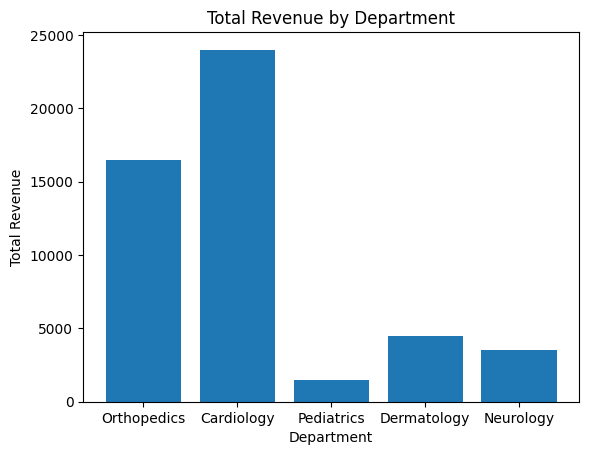

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
import matplotlib.pyplot as plt
revenue_by_department=doctor.join(appointment,doctor.doctor_id==appointment.doctor_id).groupBy("department").agg(sum("bill_amount").alias("total_revenue"))
plt.bar(revenue_by_department.toPandas()["department"],revenue_by_department.toPandas()["total_revenue"])
plt.xlabel("Department")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Department")
plt.show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


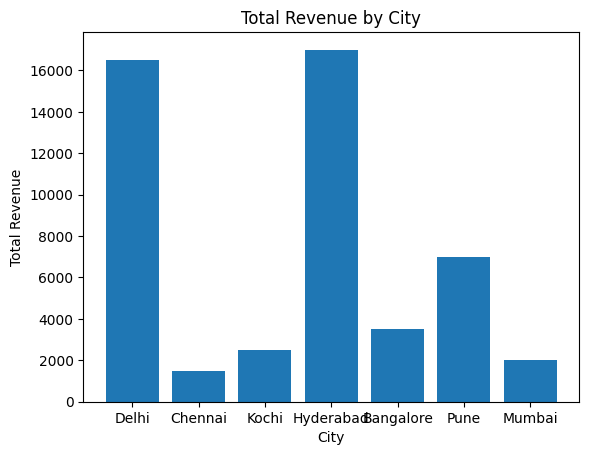

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
revenue_by_city=patients.join(appointment,patients.patient_id==appointment.patient_id).groupBy("city").agg(sum("bill_amount").alias("total_revenue"))
plt.bar(revenue_by_city.toPandas()["city"],revenue_by_city.toPandas()["total_revenue"])
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by City")
plt.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


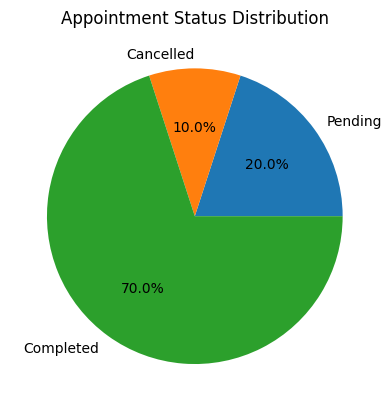

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
appointment_status=appointment.groupBy("status").count()
plt.pie(appointment_status.toPandas()["count"],labels=appointment_status.toPandas()["status"],autopct='%1.1f%%')
plt.title("Appointment Status Distribution")
plt.show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


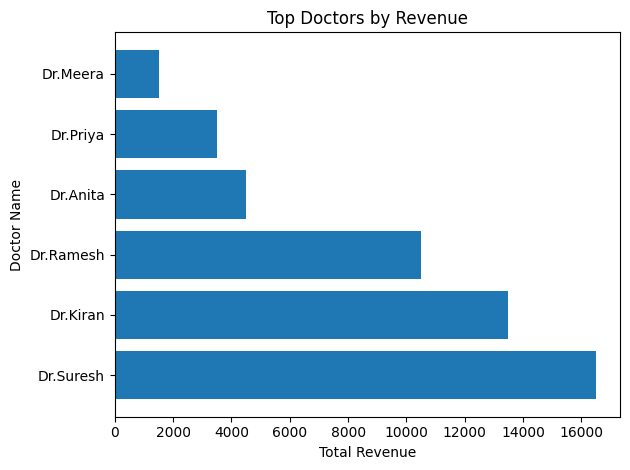

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
# Horizontal bar chart: Top Doctors by Revenue
top_doctors_revenue = doctor.join(appointment, doctor.doctor_id == appointment.doctor_id) \
    .groupBy("doctor_name") \
    .agg(sum("bill_amount").alias("total_revenue")) \
    .orderBy(col("total_revenue").desc()) \
    .limit(10)

top_doctors_pd = top_doctors_revenue.toPandas()
plt.barh(top_doctors_pd["doctor_name"], top_doctors_pd["total_revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Doctor Name")
plt.title("Top Doctors by Revenue")
plt.tight_layout()
plt.show()



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


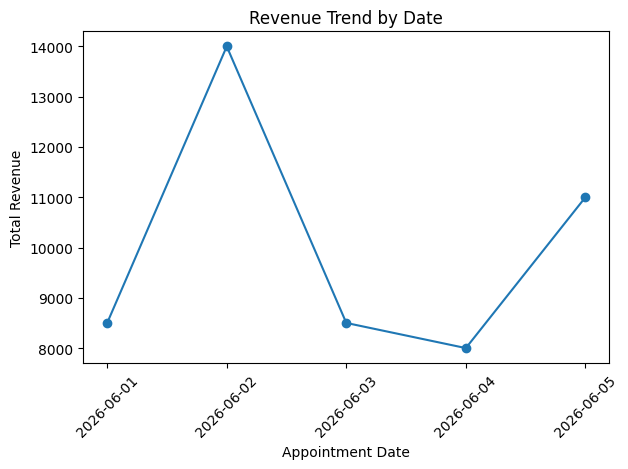

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
# Line chart: Revenue trend by date
revenue_trend = appointment.groupBy("appointment_date") \
    .agg(sum("bill_amount").alias("total_revenue")) \
    .orderBy("appointment_date")

revenue_trend_pd = revenue_trend.toPandas()
plt.plot(revenue_trend_pd["appointment_date"], revenue_trend_pd["total_revenue"], marker='o')
plt.xlabel("Appointment Date")
plt.ylabel("Total Revenue")
plt.title("Revenue Trend by Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [0]:
spark.sql("CREATE TABLE IF NOT EXISTS patient_managed AS SELECT * FROM patients")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
patients.createOrReplaceTempView("patient")


In [0]:
#patients.createGlobalTempView("patient_global")
#NOT_SUPPORTED_WITH_SERVERLESS] GLOBAL TEMPORARY VIEW is not supported on serverless compute

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-5939002755056289>, line 1
----> 1 patients.createGlobalTempView("patient_global")

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/dataframe.py:2122, in DataFrame.createGlobalTempView(self, name)
   2118 def createGlobalTempView(self, name: str) -> None:
   2119     command = plan.CreateView(
   2120         child=self._plan, name=name, is_global=True, replace=False
   2121     ).command(session=self._session.client)
-> 2122     _, _, ei = self._session.client.execute_command(command, self._plan.observations)
   2123     self._execution_info = ei

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py:1538, in SparkConnectClient.execute_command(self, command, observations, extra_request_metadata)
   1536     req.user_context.user_id = self._user_id
   1537 self._set

In [0]:
'''Global temp view can be acccessed in any notebook where normal temp view represents the local scope'''